# Importing and Observing Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_json("Master.json")

display(df.head())
display(df.info())
display(df.describe())
display(df.shape)

,session_key,driver_number,lap_number,date_start,lap_duration,air_temperature,track_temperature,humidity,rainfall,meeting_key,...,session_name,session_type,circuit_curvature,circuit_length,team_name,position,has_grid_position,stint_number,compound,tyre_age
0,7765,2,1,2023-03-03T11:30:07.574Z,NaN,27.400000,41.900000,11.0,0.0,1141,...,Practice 1,Practice,27.504929,5338.346445,Williams,0,False,1.0,HARD,0.0
1,7765,77,1,2023-03-03T11:30:09.215Z,129.966,27.400000,41.850000,11.0,0.0,1141,...,Practice 1,Practice,27.504929,5338.346445,Alfa Romeo,0,False,1.0,MEDIUM,0.0
2,7765,24,1,2023-03-03T11:30:14.011Z,140.357,27.400000,41.850000,11.0,0.0,1141,...,Practice 1,Practice,27.504929,5338.346445,Alfa Romeo,0,False,1.0,MEDIUM,0.0
3,7765,4,1,2023-03-03T11:30:16.168Z,128.935,27.400000,41.850000,11.0,0.0,1141,...,Practice 1,Practice,27.504929,5338.346445,McLaren,0,False,1.0,MEDIUM,0.0
4,7765,81,1,2023-03-03T11:30:26.277Z,142.794,27.366667,41.833333,11.0,0.0,1141,...,Practice 1,Practice,27.504929,5338.346445,McLaren,0,False,1.0,MEDIUM,0.0


<class 'pandas.DataFrame'>
RangeIndex: 228212 entries, 0 to 228211
Data columns (total 22 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   session_key         228212 non-null  int64  
 1   driver_number       228212 non-null  int64  
 2   lap_number          228212 non-null  int64  
 3   date_start          228212 non-null  str    
 4   lap_duration        219719 non-null  float64
 5   air_temperature     228212 non-null  float64
 6   track_temperature   228212 non-null  float64
 7   humidity            228212 non-null  float64
 8   rainfall            228212 non-null  float64
 9   meeting_key         228212 non-null  int64  
 10  circuit_key         228212 non-null  int64  
 11  circuit_short_name  228212 non-null  str    
 12  session_name        228212 non-null  str    
 13  session_type        228212 non-null  str    
 14  circuit_curvature   228212 non-null  float64
 15  circuit_length      228212 non-null  float64


None

,session_key,driver_number,lap_number,lap_duration,air_temperature,track_temperature,humidity,rainfall,meeting_key,circuit_key,circuit_curvature,circuit_length,position,stint_number,tyre_age
count,228212.00000,228212.000000,228212.000000,219719.000000,228212.000000,228212.000000,228212.000000,228212.000000,228212.000000,228212.000000,228212.000000,228212.000000,228212.000000,216429.000000,216429.000000
mean,9762.40178,29.537356,20.205055,130.897726,23.907083,36.158116,51.466635,0.032433,1245.451918,51.478494,29.377707,5007.393096,4.894116,2.442672,9.432742
std,754.32316,24.302899,16.399963,152.338399,5.020175,9.029598,16.467927,0.172564,30.658504,51.094789,5.165989,862.872515,6.545463,1.358380,9.968139
min,7765.00000,1.000000,1.000000,60.351000,10.800000,0.000000,11.000000,0.000000,1141.000000,2.000000,18.981483,3274.691675,0.000000,1.000000,0.000000
25%,9278.00000,11.000000,8.000000,82.778500,20.400000,30.650000,38.500000,0.000000,1226.000000,14.000000,26.923364,4312.661993,0.000000,1.000000,2.000000
50%,9621.00000,22.000000,16.000000,94.677000,24.200000,36.560000,53.000000,0.000000,1247.000000,23.000000,29.630629,5230.800765,0.000000,2.000000,6.000000
75%,9963.00000,44.000000,28.000000,111.354000,27.650000,42.900000,63.000000,0.000000,1268.000000,65.000000,31.360061,5760.133627,10.000000,3.000000,14.000000
max,11342.00000,98.000000,79.000000,3225.697000,35.750000,60.600000,96.000000,1.000000,1291.000000,152.000000,39.026689,6954.107756,22.000000,11.000000,78.000000


(228212, 22)

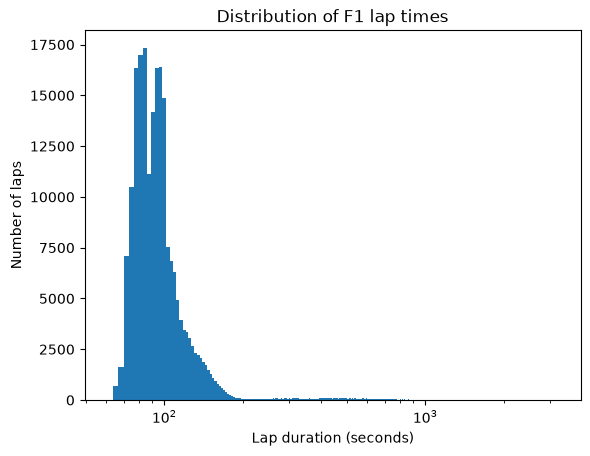

In [2]:
plt.hist(df["lap_duration"], bins=1000)
plt.xscale("log")
plt.xlabel("Lap duration (seconds)")
plt.ylabel("Number of laps")
plt.title("Distribution of F1 lap times")
plt.show()

# Observe this graph is wildly left-skewed. This will be addressed.

# Cleaning Data

In [3]:
df["date_dt"] = pd.to_datetime(df["date_start"], utc=True)

df["elapsed_session_min"] = (
    df["date_dt"]
    - df.groupby("session_key")["date_dt"].transform("min")
).dt.total_seconds() / 60

ordered = df.sort_values(
    ["session_key", "driver_number", "lap_number", "date_dt"]
).copy()

driver_session = ordered.groupby(
    ["session_key", "driver_number"],
    sort=False
)["lap_duration"]

ordered["previous_lap_duration"] = driver_session.shift(1)

ordered["previous_3_lap_median"] = driver_session.transform(
    lambda laps: laps.shift(1).rolling(3, min_periods=1).median()
)

df.loc[
    ordered.index,
    ["previous_lap_duration", "previous_3_lap_median"]
] = ordered[
    ["previous_lap_duration", "previous_3_lap_median"]
]

stint_min_lap = df.groupby(
    ["session_key", "driver_number", "stint_number"],
    dropna=False
)["lap_number"].transform("min")

df["is_stint_start"] = df["lap_number"].eq(stint_min_lap)

# session_key, meeting_key, circuit_short_name, and session_type are extraneous
df_temp = df.drop(columns=["session_key", "meeting_key", "circuit_short_name", "session_type"]).dropna().drop_duplicates()

# Within lap times, the maximum values are drastically large, and it can be reasonably assumed they are erronious.
# Thus I will remove the 90th percentile of laps so the regression models won't be penalized by unrealistic lap times.
cutoff = df_temp["lap_duration"].quantile(0.90)
df_cleaned = df_temp[df_temp["lap_duration"] <= cutoff]

# Maybe we make this 90th instead?

display(df_cleaned[["lap_duration"]].describe())
display(df_cleaned.info())
display(df_cleaned.describe())

,lap_duration
count,178780.000000
mean,94.313529
std,17.085286
min,60.351000
25%,81.423000
50%,91.838000
75%,101.656000
max,147.120000


<class 'pandas.DataFrame'>
Index: 178780 entries, 15 to 228211
Data columns (total 23 columns):
 #   Column                 Non-Null Count   Dtype              
---  ------                 --------------   -----              
 0   driver_number          178780 non-null  int64              
 1   lap_number             178780 non-null  int64              
 2   date_start             178780 non-null  str                
 3   lap_duration           178780 non-null  float64            
 4   air_temperature        178780 non-null  float64            
 5   track_temperature      178780 non-null  float64            
 6   humidity               178780 non-null  float64            
 7   rainfall               178780 non-null  float64            
 8   circuit_key            178780 non-null  int64              
 9   session_name           178780 non-null  str                
 10  circuit_curvature      178780 non-null  float64            
 11  circuit_length         178780 non-null  float64       

None

,driver_number,lap_number,lap_duration,air_temperature,track_temperature,humidity,rainfall,circuit_key,circuit_curvature,circuit_length,position,stint_number,tyre_age,elapsed_session_min,previous_lap_duration,previous_3_lap_median
count,178780.000000,178780.000000,178780.000000,178780.000000,178780.000000,178780.000000,178780.000000,178780.000000,178780.000000,178780.000000,178780.000000,178780.000000,178780.000000,178780.000000,178780.000000,178780.000000
mean,29.523079,22.775126,94.313529,23.849633,36.049127,51.604012,0.032375,51.022061,29.378021,4962.749398,5.778952,2.441006,10.746236,40.346087,132.850908,104.407134
std,24.275784,16.721591,17.085286,4.977618,9.056018,16.303054,0.173746,50.779403,5.253072,865.802020,6.745013,1.307333,10.149710,24.907144,156.353121,69.516908
min,1.000000,2.000000,60.351000,10.800000,0.000000,11.000000,0.000000,2.000000,18.981483,3274.691675,0.000000,1.000000,0.000000,0.000000,63.971000,65.190000
25%,11.000000,10.000000,81.423000,20.300000,30.500000,39.000000,0.000000,14.000000,26.128704,4296.363485,0.000000,1.000000,3.000000,18.921067,82.218000,83.096000
50%,22.000000,18.000000,91.838000,24.050000,36.400000,53.000000,0.000000,23.000000,29.630629,5230.800765,2.000000,2.000000,8.000000,38.851908,93.472500,94.549000
75%,44.000000,32.000000,101.656000,27.450000,43.000000,63.000000,0.000000,65.000000,31.360061,5427.374488,11.000000,3.000000,15.000000,57.637888,107.721000,106.961000
max,98.000000,78.000000,147.120000,35.700000,60.600000,96.000000,1.000000,152.000000,39.026689,6954.107756,22.000000,11.000000,78.000000,143.663333,3225.697000,3225.697000


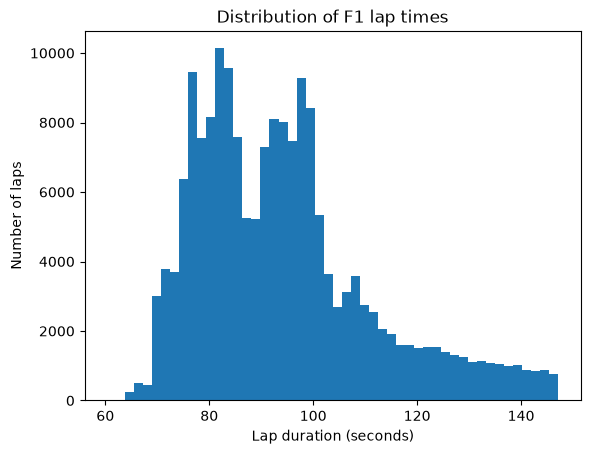

In [4]:
plt.hist(df_cleaned["lap_duration"], bins=50)
plt.xlabel("Lap duration (seconds)")
plt.ylabel("Number of laps")
plt.title("Distribution of F1 lap times")
plt.show()

# Feature Preprocessing

In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures

print(df_cleaned.columns)

Index(['driver_number', 'lap_number', 'date_start', 'lap_duration',
       'air_temperature', 'track_temperature', 'humidity', 'rainfall',
       'circuit_key', 'session_name', 'circuit_curvature', 'circuit_length',
       'team_name', 'position', 'has_grid_position', 'stint_number',
       'compound', 'tyre_age', 'date_dt', 'elapsed_session_min',
       'previous_lap_duration', 'previous_3_lap_median', 'is_stint_start'],
      dtype='str')


In [ ]:

categorical_features = ["driver_number", "circuit_key", "session_name", "team_name", "compound"]
numerical_features = ["air_temperature", "track_temperature", "humidity",
                      "rainfall", "position", "has_grid_position",
                      "tyre_age", "stint_number", "lap_number",
                      "circuit_curvature", "circuit_length", "previous_lap_duration",
                      "is_stint_start", "previous_3_lap_median"
                      ]

X = df_cleaned[[*categorical_features, *numerical_features]]
y = df_cleaned[["lap_duration"]]

numeric_transformer = Pipeline(
    steps=[
        ("polynomial", PolynomialFeatures(degree=2, include_bias=False)),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("encoder", OneHotEncoder(sparse_output=False))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numerical", numeric_transformer, numerical_features),
        ("categorical", categorical_transformer, categorical_features)
    ]
)

In [7]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.compose import TransformedTargetRegressor

# Observe
linear_pipeline = Pipeline(
    steps=[("preprocessor", preprocessor), ("classifier", LinearRegression())]
)

clf = TransformedTargetRegressor(
    regressor=linear_pipeline,
    func = np.log1p,
    inverse_func = np.expm1
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf.fit(X_train, y_train)
linear_pipeline.fit(X_train, y_train)
y_pred_log = clf.predict(X_test)
y_pred_none = linear_pipeline.predict(X_test)

from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
print("Log:")
print("MAE: ", mean_absolute_error(y_test, y_pred_log))
print("RMSE: ", root_mean_squared_error(y_test, y_pred_log))
print("R2: ", r2_score(y_test, y_pred_log))
print("None:")
print("MAE: ", mean_absolute_error(y_test, y_pred_none))
print("RMSE: ", root_mean_squared_error(y_test, y_pred_none))
print("R2: ", r2_score(y_test, y_pred_none))

clf

TypeError: Cannot cast DatetimeArray to dtype float64

In [ ]:
display(X_test.head())
display(y_test.head())

X_test_racing = X_test[X_test["session_name"] == "Race"]
y_test_racing = y_test[X_test["session_name"] == "Race"]

y_pred_racing = linear_pipeline.predict(X_test_racing)
print("Races:")
print("MAE: ", mean_absolute_error(y_test_racing, y_pred_racing))
print("RMSE: ", root_mean_squared_error(y_test_racing, y_pred_racing))
print("R2: ", r2_score(y_test_racing, y_pred_racing))

In [ ]:
'''def build_polynomial_model(degree, regression_model = LinearRegression()):
    numeric_transformer = Pipeline(
        steps=[
            ("polynomial", PolynomialFeatures(degree=degree, include_bias=False)),
            ("scaler", StandardScaler())
        ]
    )

    categorical_transformer = Pipeline(
        steps=[
            ("encoder", OneHotEncoder(sparse_output=False))
        ]
    )

    preprocessor = ColumnTransformer(
        transformers=[
            ("numerical", numeric_transformer, numerical_features),
            ("categorical", categorical_transformer, categorical_features)
        ]
    )
    model = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", regression_model)
    ])
    return model'''

In [ ]:
'''degrees = [1, 2, 3]
cv = KFold(n_splits = 3, shuffle=True, random_state=42)

models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha = 0.1),
    "Lasso": Lasso(alpha = 0.1),
    "ElasticNet": ElasticNet(alpha = 0.1, l1_ratio = 0.5)
}

for degree in degrees:
    stats = []
    coef_data = {}
    for name, reg in models.items():
        model = build_polynomial_model(degree, regression_model = reg)

        cv_results = cross_validate(
            model,
            X_train,
            y_train,
            cv = cv,
            scoring = "neg_root_mean_squared_error",
            return_train_score = True
        )

        train_rmse_scores = -cv_results["train_score"]
        cv_rmse_scores = -cv_results["test_score"]

        model.fit(X_train, y_train)
        #feature_names = model.named_steps["polynomial_features"].get_feature_names_out(["x"])

        coefficients = np.ravel(model.named_steps["classifier"].coef_)
        
        nonzero_count = np.sum(coefficients != 0)
        
        stats.append({
            "Model": name,
            "Mean Training RMSE": train_rmse_scores.mean(),
            "Mean CV RMSE": cv_rmse_scores.mean(),
            "CV RMSE Std": cv_rmse_scores.std(),
            "Nonzero Coefficients": nonzero_count
        })
        coef_data[name] = coefficients
    print(degree)
    stats_df = pd.DataFrame(stats).set_index("Model").transpose()
    display(stats_df)
    coef_df = pd.DataFrame.from_dict(coef_data)
    display(coef_df)'''